# Experiment 2 – AdaBoost Classifier

Implement an AdaBoost ensemble classifier on the Iris dataset.  
Train the model using different numbers of weak learners and learning rate values.  
Evaluate performance using accuracy, confusion matrix, classification report, and precision-recall curve.


 Accuracy: 1.0


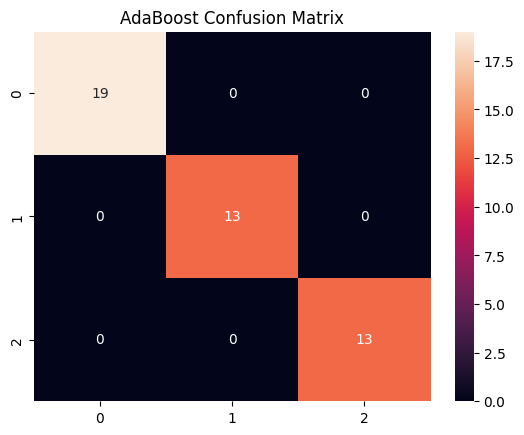


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



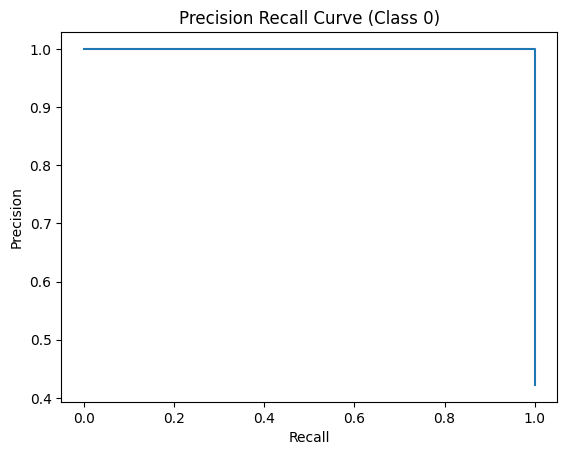

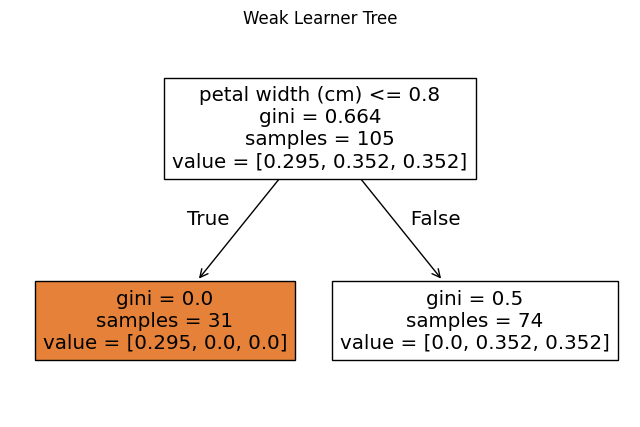

In [6]:
# EXPERIMENT 2 — AdaBoost

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)
from sklearn.preprocessing import label_binarize
from sklearn import tree

# Load dataset
data = load_iris()
X = data.data
y = data.target

# Binarize
y_bin = label_binarize(y, classes=[0,1,2])

# Split
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(
    X, y, y_bin, test_size=0.3, random_state=42
)

# AdaBoost
base = DecisionTreeClassifier(max_depth=1)

model = AdaBoostClassifier(
    estimator=base,
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Accuracy
print("\n Accuracy:", accuracy_score(y_test, y_pred))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d")
plt.title("AdaBoost Confusion Matrix")
plt.show()

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# Precision Recall curve (class 0 vs rest)
y_prob = model.predict_proba(X_test)

precision, recall, _ = precision_recall_curve(
    y_test_bin[:,0],
    y_prob[:,0]
)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision Recall Curve (Class 0)")
plt.show()

# Visualize weak learner
plt.figure(figsize=(8,5))

tree.plot_tree(
    model.estimators_[0],
    feature_names=data.feature_names,
    filled=True
)

plt.title("Weak Learner Tree")
plt.show()